# Offline run analysis

Set `RUN_ID` to an existing online run folder for raw input data, and set `OFFLINE_RUN_ID` for this offline analysis pass. This notebook loads raw training and realtime trial `.npz` files from `runs/<RUN_ID>/`, applies its own preprocessing and audio-cue labeling settings, trains offline model variants, tests each on the realtime trial, and saves all notebook-03 outputs under `runs_offline/<OFFLINE_RUN_ID>/`. Models use time-domain EEG windows after this notebook's preprocessing step.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'training.py').exists():
    ROOT = Path(r'D:/BME/BCI/online_bci/online_eeg')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from preprocessing import (
    AudioLabelConfig,
    PreprocessConfig,
    labeled_preprocess_summary,
    preprocess_recording,
)
from training import TrainingConfig, offline_train_test_sweep
from plots import plot_labeled_recording, plot_predictions_overlay

print('Pipeline root:', ROOT)


Pipeline root: d:\BME\BCI\online_bci\online_eeg


## Raw files, preprocessing, and sweep settings


In [2]:
RUN_ID = 'run_001'
RUN_DIR = ROOT / 'runs' / RUN_ID

OFFLINE_RUN_ID = 'offline_001'  # Change this to keep a separate set of 03 outputs.
OFFLINE_ROOT = ROOT / 'runs_offline'
OFFLINE_RUN_DIR = OFFLINE_ROOT / OFFLINE_RUN_ID

TRAIN_RAW_NPZ = RUN_DIR / 'raw_training' / 'train_01.npz'
TEST_RAW_NPZ = RUN_DIR / 'realtime_trials' / 'realtime_trial_01_raw.npz'

EEG_CHANNELS = (1, 2, 3, 4)
EEG_CHANNEL_NAMES = ('O1', 'Oz', 'O2', 'POz')
AUDIO_CHANNEL = 16

APPLY_SOFTWARE_FILTERS = True  # BIOPAC hardware already bandpasses the EEG at 1-35 Hz.
DEMEAN_CHANNELS = True
SOFTWARE_BANDPASS_HZ = (8.0, 35.0)  # Set to (8.0, 35.0) to filter out blinks only if APPLY_SOFTWARE_FILTERS=True.
SOFTWARE_NOTCH_HZ = (60.0,)  # Set to (60.0,) only if APPLY_SOFTWARE_FILTERS=True.
PREPROCESS_TAG = 'software_filters_on' if APPLY_SOFTWARE_FILTERS else 'hardware_filter_only'
if DEMEAN_CHANNELS:
    PREPROCESS_TAG += '_demeaned'

OFFLINE_LABELED_DIR = OFFLINE_RUN_DIR / 'labeled'
TRAIN_LABELED_NPZ = OFFLINE_LABELED_DIR / f'{TRAIN_RAW_NPZ.stem}_labeled.npz'
TEST_LABELED_NPZ = OFFLINE_LABELED_DIR / f'{TEST_RAW_NPZ.stem}_labeled.npz'
SWEEP_DIR = OFFLINE_RUN_DIR / 'sweeps'

FEATURE_MODES = ('filtered_signal',)

# WINDOW_SECS = (1.0, 2.0, 3.0)
WINDOW_SECS = (0.5, 1.0, 1.5, 2.0)
# STRIDE_SECS = (0.05, 0.1, 0.2)
STRIDE_SECS = (0.05, 0.1, 0.15, 0.2)
LABEL_MODES = ('endpoint', 'majority')  # Include one or both: 'endpoint', 'majority'.

PRE = PreprocessConfig(
    eeg_channels=EEG_CHANNELS,
    audio_channel=AUDIO_CHANNEL,
    apply_software_filters=APPLY_SOFTWARE_FILTERS,
    bandpass_low_hz=None if SOFTWARE_BANDPASS_HZ is None else SOFTWARE_BANDPASS_HZ[0],
    bandpass_high_hz=None if SOFTWARE_BANDPASS_HZ is None else SOFTWARE_BANDPASS_HZ[1],
    notch_hz=SOFTWARE_NOTCH_HZ,
    notch_quality_factor=30.0,
    filter_order=4,
    demean_channels=DEMEAN_CHANNELS,
)

LABELS = AudioLabelConfig(
    class_names=('Eyes Open', 'Eyes Closed'),
    baseline_label=0,
    active_label=1,
    cue_label_sequence=None,
    alternate_binary_labels=True,
    label_duration_sec=None,  # transition mode: each cue switches state until the next cue.
    label_start_offset_sec=0.0,  # label switch starts exactly at cue onset.
    envelope_window_sec=0.025,
    onset_threshold=None,
    onset_min_interval_sec=0.50,
)

TRAIN = TrainingConfig(
    train_fraction=0.9,
    hidden_size=64,
    num_layers=2,
    dropout=0.25,
    batch_size=64,
    epochs=20,
    lr=1e-3,
    seed=888,
)

if not RUN_DIR.exists():
    raise FileNotFoundError(f'Run folder not found: {RUN_DIR}')
if not TRAIN_RAW_NPZ.exists():
    raise FileNotFoundError(f'Training raw file not found: {TRAIN_RAW_NPZ}')
if not TEST_RAW_NPZ.exists():
    raise FileNotFoundError(f'Test raw file not found: {TEST_RAW_NPZ}')

OFFLINE_LABELED_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_DIR.mkdir(parents=True, exist_ok=True)
print('Run directory:', RUN_DIR)
print('Offline root:', OFFLINE_ROOT)
print('Offline run directory:', OFFLINE_RUN_DIR)
print('Training raw file:', TRAIN_RAW_NPZ)
print('Test raw file:', TEST_RAW_NPZ)
print('Offline labeled output:', OFFLINE_LABELED_DIR)
print('Sweep output:', SWEEP_DIR)
print('Preprocess tag:', PREPROCESS_TAG)
print('Software filters enabled:', APPLY_SOFTWARE_FILTERS)


Run directory: d:\BME\BCI\online_bci\online_eeg\runs\run_001
Offline root: d:\BME\BCI\online_bci\online_eeg\runs_offline
Offline run directory: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001
Training raw file: d:\BME\BCI\online_bci\online_eeg\runs\run_001\raw_training\train_01.npz
Test raw file: d:\BME\BCI\online_bci\online_eeg\runs\run_001\realtime_trials\realtime_trial_01_raw.npz
Offline labeled output: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\labeled
Sweep output: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps
Preprocess tag: software_filters_on_demeaned
Software filters enabled: True


## Preprocess raw files for this offline analysis


In [3]:
TRAIN_LABELED_NPZ, train_cue_table = preprocess_recording(
    raw_npz=TRAIN_RAW_NPZ,
    output_npz=TRAIN_LABELED_NPZ,
    preprocess_config=PRE,
    label_config=LABELS,
)
TEST_LABELED_NPZ, test_cue_table = preprocess_recording(
    raw_npz=TEST_RAW_NPZ,
    output_npz=TEST_LABELED_NPZ,
    preprocess_config=PRE,
    label_config=LABELS,
)

preprocess_summary = labeled_preprocess_summary({
    'training': TRAIN_LABELED_NPZ,
    'realtime_test': TEST_LABELED_NPZ,
})
display(preprocess_summary)

print('Training cue table')
display(train_cue_table)
print('Realtime test cue table')
display(test_cue_table)


,name,path,samplerate,duration_sec,has_preprocess_config,has_apply_software_filters_flag,apply_software_filters,demean_channels,bandpass_low_hz,bandpass_high_hz,notch_hz,eeg_channels,audio_channel,source_raw_npz
0,training,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,200,300.0,True,True,True,True,8.0,35.0,[60.0],"[1, 2, 3, 4]",16,d:\BME\BCI\online_bci\online_eeg\runs\run_001\...
1,realtime_test,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,200,30.0,True,True,True,True,8.0,35.0,[60.0],"[1, 2, 3, 4]",16,d:\BME\BCI\online_bci\online_eeg\runs\run_001\...


Training cue table


,cue_index,onset_sample,onset_time_sec,label_start_sample,label_end_sample,label_start_time_sec,label_end_time_sec,label,label_name,peak_value
0,0,1155,5.775,1155,2163,5.775,10.815,1,Eyes Closed,1.030212
1,1,2163,10.815,2163,3135,10.815,15.675,0,Eyes Open,1.040991
2,2,3135,15.675,3135,4183,15.675,20.915,1,Eyes Closed,1.046932
3,3,4183,20.915,4183,5851,20.915,29.255,0,Eyes Open,1.041953
4,4,5851,29.255,5851,7508,29.255,37.540,1,Eyes Closed,1.047938
5,5,7508,37.540,7508,8295,37.540,41.475,0,Eyes Open,1.047303
6,6,8295,41.475,8295,9107,41.475,45.535,1,Eyes Closed,1.044649
7,7,9107,45.535,9107,11099,45.535,55.495,0,Eyes Open,1.044290
8,8,11099,55.495,11099,13139,55.495,65.695,1,Eyes Closed,1.039200
9,9,13139,65.695,13139,13711,65.695,68.555,0,Eyes Open,1.049705


Realtime test cue table


,cue_index,onset_sample,onset_time_sec,label_start_sample,label_end_sample,label_start_time_sec,label_end_time_sec,label,label_name,peak_value
0,0,1715,8.575,1715,3331,8.575,16.655,1,Eyes Closed,1.038022
1,1,3331,16.655,3331,5030,16.655,25.150,0,Eyes Open,1.035590
2,2,5030,25.150,5030,6000,25.150,30.000,1,Eyes Closed,1.040509


## Inspect freshly labeled train/test data


Text(0.5, 1.0, 'Training labeled EEG preview')

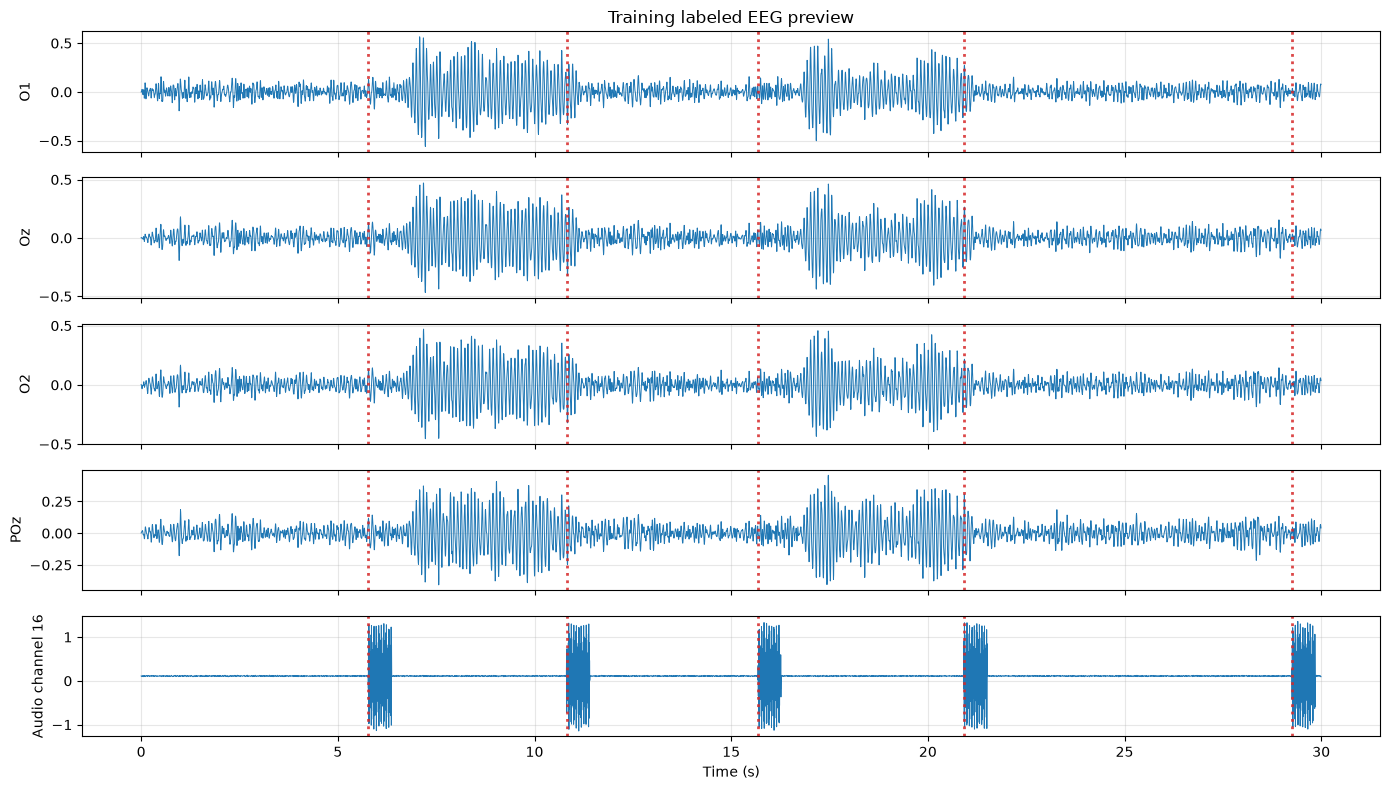

In [4]:
fig, axes = plot_labeled_recording(
    TRAIN_LABELED_NPZ,
    max_duration_sec=30.0,
    channel_names=EEG_CHANNEL_NAMES,
)
axes[0].set_title('Training labeled EEG preview')


Text(0.5, 1.0, 'Realtime trial labeled EEG preview')

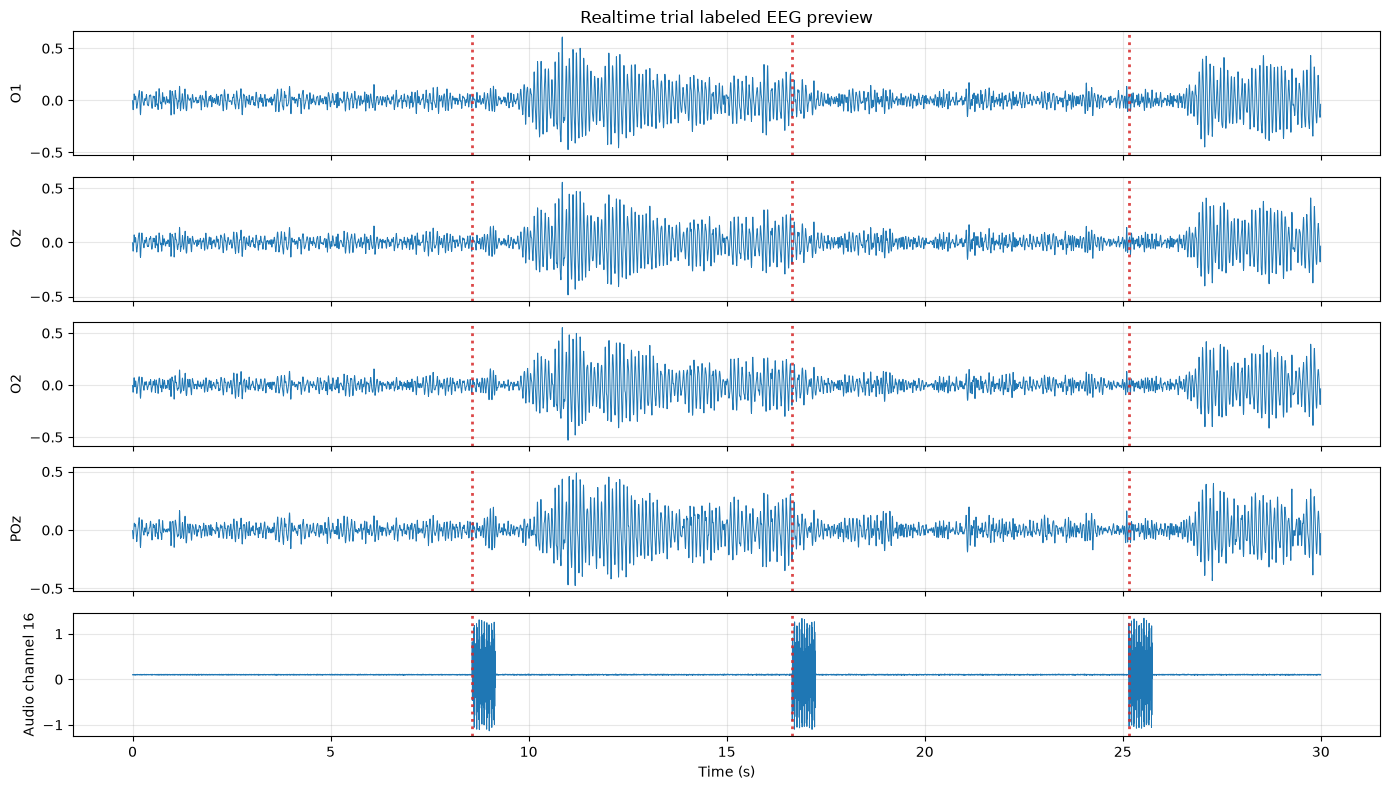

In [5]:
fig, axes = plot_labeled_recording(
    TEST_LABELED_NPZ,
    max_duration_sec=None,
    channel_names=EEG_CHANNEL_NAMES,
)
axes[0].set_title('Realtime trial labeled EEG preview')


## Run offline model sweep


In [6]:
sweep_result = offline_train_test_sweep(
    train_labeled_npz=TRAIN_LABELED_NPZ,
    test_labeled_npz=TEST_LABELED_NPZ,
    output_dir=SWEEP_DIR,
    feature_modes=FEATURE_MODES,
    window_secs=WINDOW_SECS,
    stride_secs=STRIDE_SECS,
    training_config=TRAIN,
    label_modes=LABEL_MODES,
)

RANK_COLUMN = 'test_xcov_peak_coeff'
summary = sweep_result['summary'].copy()
if RANK_COLUMN not in summary.columns:
    raise KeyError(f'Missing ranking column: {RANK_COLUMN}')
summary = (
    summary
    .sort_values(
        [RANK_COLUMN, 'test_balanced_accuracy', 'val_balanced_accuracy'],
        ascending=[False, False, False],
        na_position='last',
    )
    .reset_index(drop=True)
)
print('Saved sweep summary:', sweep_result['summary_csv'])
print(f'Ranked variants by {RANK_COLUMN} descending; balanced accuracy is used only as a tie-breaker.')
display(summary)


Saved sweep summary: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\offline_sweep_summary.csv
Ranked variants by test_xcov_peak_coeff descending; balanced accuracy is used only as a tie-breaker.


,variant,feature_mode,label_mode,window_sec,stride_sec,checkpoint_path,variant_dir,validation_aligned_prediction_csv,test_aligned_prediction_csv,val_accuracy,...,test_n_windows,test_mean_cue_to_first_correct_sec,test_median_cue_to_first_correct_sec,test_mean_cue_to_predicted_transition_sec,test_median_cue_to_predicted_transition_sec,test_mean_cue_to_sustained_prediction_sec,test_median_cue_to_sustained_prediction_sec,test_xcov_delay_sec,test_xcov_peak_coeff,test_xcov_signal_column
0,filtered_signal__win_2p0s__stride_0p05s__label...,filtered_signal,majority,2.0,0.05,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,0.969799,...,561.0,1.590000,1.675,1.590000,1.675,1.590000,1.675,1.695,0.977403,prob_Eyes Closed
1,filtered_signal__win_2p0s__stride_0p1s__labels...,filtered_signal,majority,2.0,0.10,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,0.966443,...,281.0,1.606667,1.625,1.606667,1.625,1.706667,1.645,1.625,0.968936,prob_Eyes Closed
2,filtered_signal__win_1p5s__stride_0p2s__labels...,filtered_signal,majority,1.5,0.20,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,0.959732,...,143.0,1.573333,1.725,1.573333,1.725,1.573333,1.725,1.725,0.967289,prob_Eyes Closed
3,filtered_signal__win_2p0s__stride_0p15s__label...,filtered_signal,majority,2.0,0.15,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,0.949749,...,187.0,1.656667,1.675,1.656667,1.675,1.656667,1.675,1.675,0.962809,prob_Eyes Closed
4,filtered_signal__win_1p5s__stride_0p15s__label...,filtered_signal,majority,1.5,0.15,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,0.954774,...,191.0,1.506667,1.625,1.506667,1.625,1.506667,1.625,1.625,0.953554,prob_Eyes Closed
5,filtered_signal__win_1p5s__stride_0p1s__labels...,filtered_signal,majority,1.5,0.10,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,0.959866,...,286.0,1.540000,1.625,1.540000,1.625,1.540000,1.625,1.625,0.949498,prob_Eyes Closed
6,filtered_signal__win_1p5s__stride_0p05s__label...,filtered_signal,majority,1.5,0.05,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,0.956449,...,571.0,1.440000,1.625,1.440000,1.625,1.440000,1.625,1.625,0.948287,prob_Eyes Closed
7,filtered_signal__win_1p5s__stride_0p05s__label...,filtered_signal,endpoint,1.5,0.05,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,0.894472,...,571.0,1.406667,1.575,1.406667,1.575,1.406667,1.575,1.575,0.937049,prob_Eyes Closed
8,filtered_signal__win_2p0s__stride_0p2s__labels...,filtered_signal,majority,2.0,0.20,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,d:\BME\BCI\online_bci\online_eeg\runs_offline\...,0.973154,...,141.0,1.540000,1.625,1.540000,1.625,1.540000,1.625,1.825,0.936993,prob_Eyes Closed
9,filtered_signal__win_2p0s__stride_0p15s__label...,filtered_signal,endpoint

## Compare variants


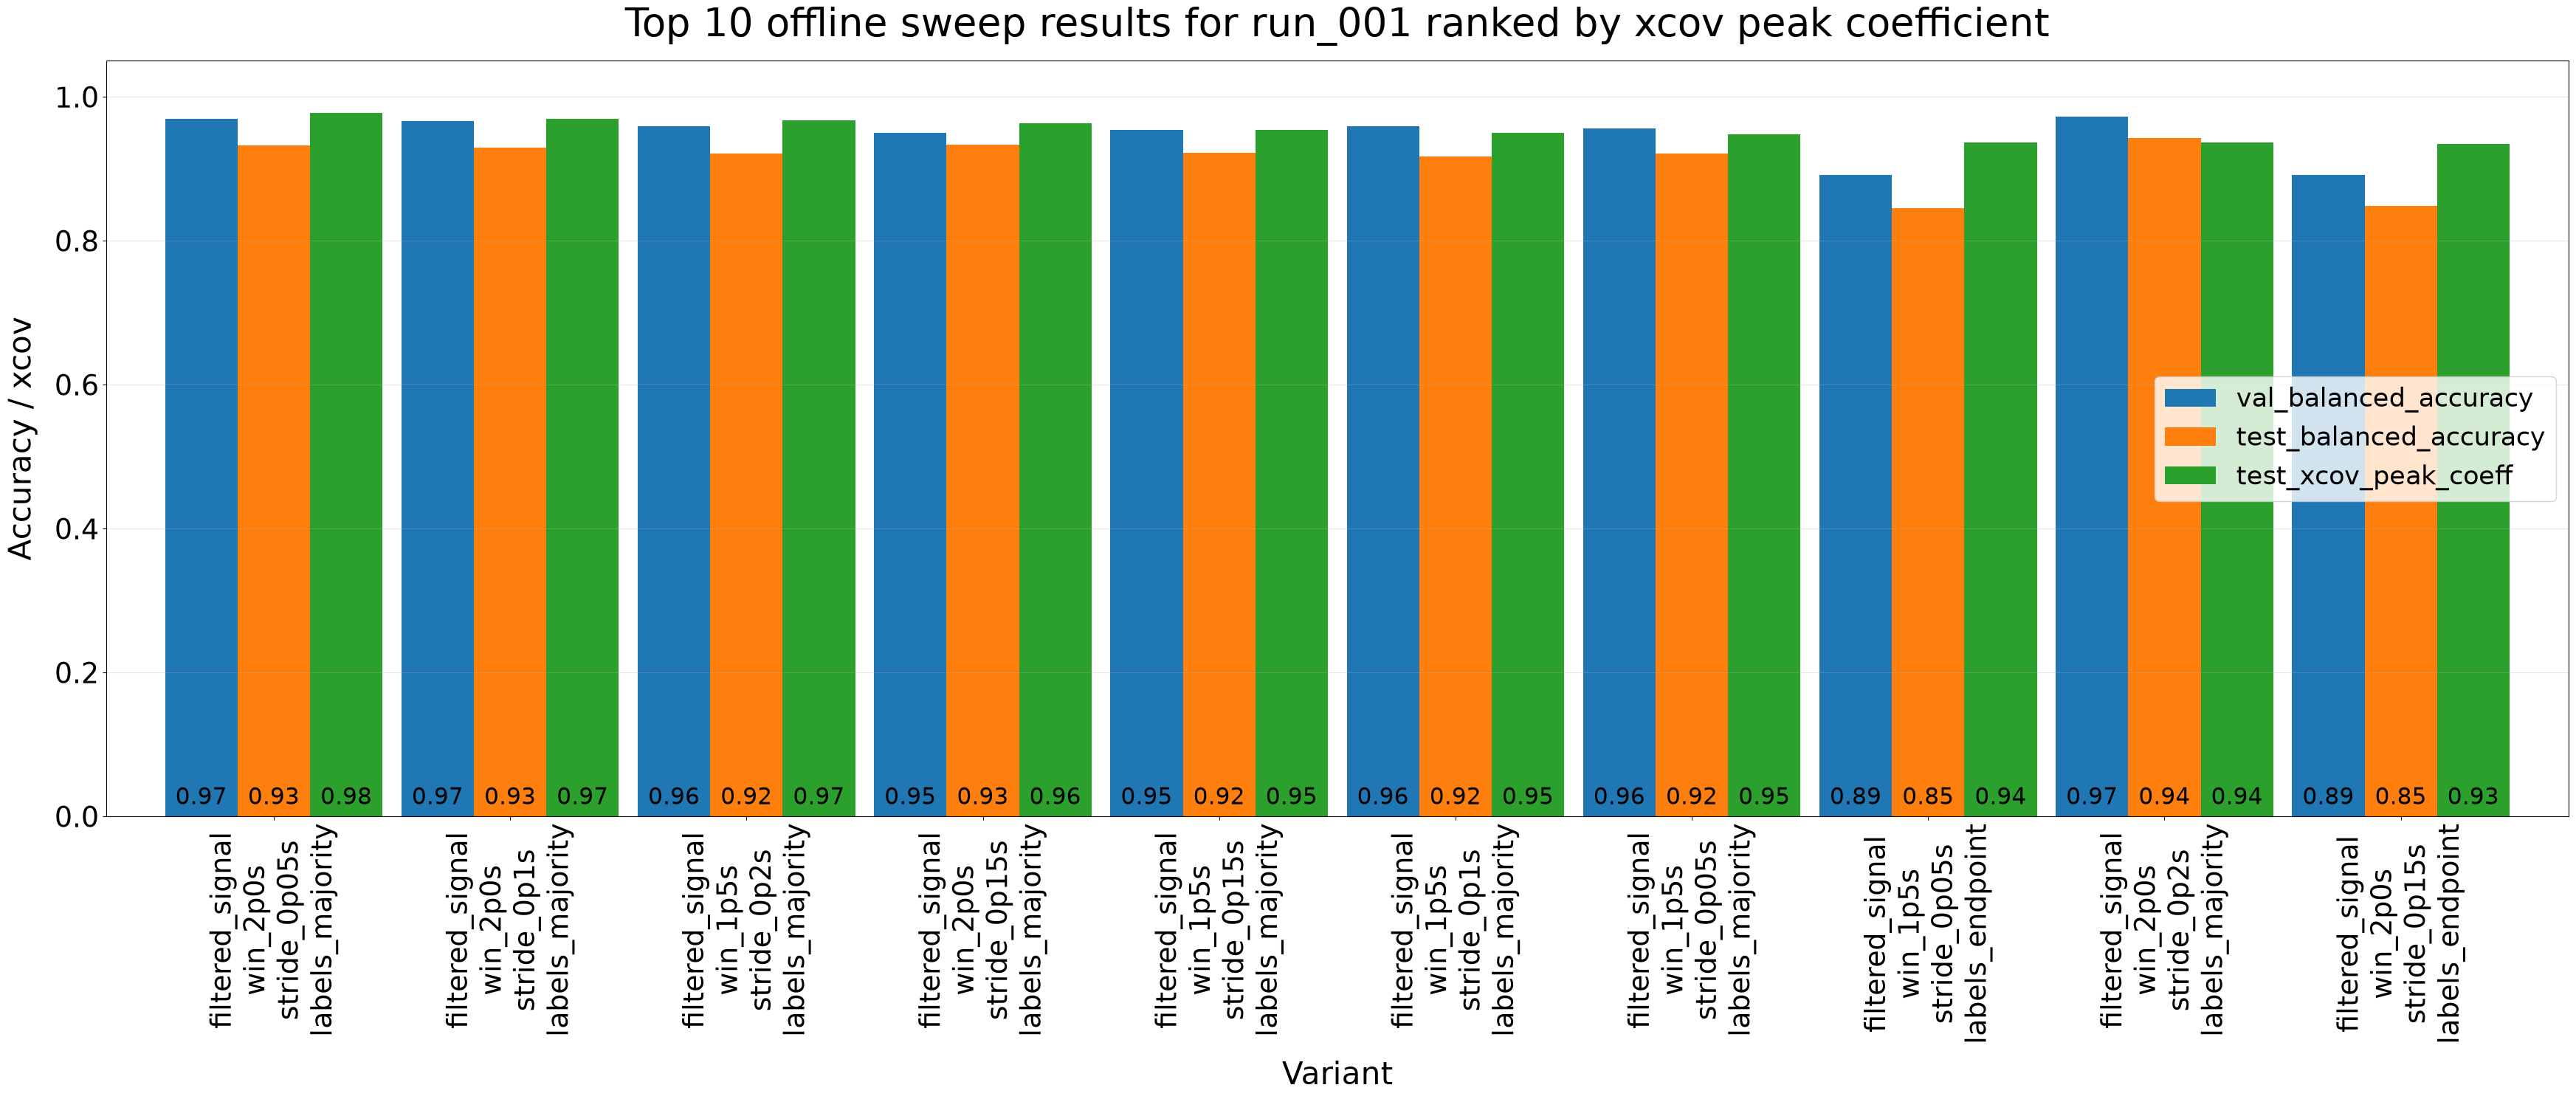

In [ ]:
TOP_N_VARIANTS = 10
plot_df = summary.head(TOP_N_VARIANTS).copy()
plot_df['variant_short'] = plot_df['variant'].str.replace('__', '\n', regex=False)
plot_df['test_xcov_peak_coeff'] = pd.to_numeric(plot_df['test_xcov_peak_coeff'], errors='coerce')
ax = plot_df.plot.bar(
    x='variant_short',
    y=['val_balanced_accuracy', 'test_balanced_accuracy', 'test_xcov_peak_coeff'],
    figsize=(35, 15),
    width=0.92,
)
ax.set_xlabel('Variant', fontsize=30, labelpad=16)
ax.set_ylabel('Accuracy / xcov', fontsize=30, labelpad=16)
ax.set_ylim(0.0, 1.05)
ax.set_title(
    f'Top {TOP_N_VARIANTS} offline sweep results for {RUN_ID} ranked by xcov peak coefficient',
    fontsize=38,
    pad=24,
)
ax.tick_params(axis='x', labelsize=27, rotation=90)
ax.tick_params(axis='y', labelsize=27)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                0.025,
                f'{float(height):.2f}',
                ha='center',
                va='bottom',
                fontsize=22,
                color='black',
                clip_on=True,
            )
ax.legend(fontsize=25, loc='center right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()


## Compare variants by causal delay

The xcov lag is signed: positive delay means the prediction trace lags the label trace, while negative delay means the prediction trace leads the label trace. For a causal real-time model, negative delay should not be rewarded in the main delay ranking. This plot ranks variants with nonnegative xcov delay first, because those represent predictions that follow the label transition. Negative-delay variants remain in the full summary table but are placed after all nonnegative-delay variants here.


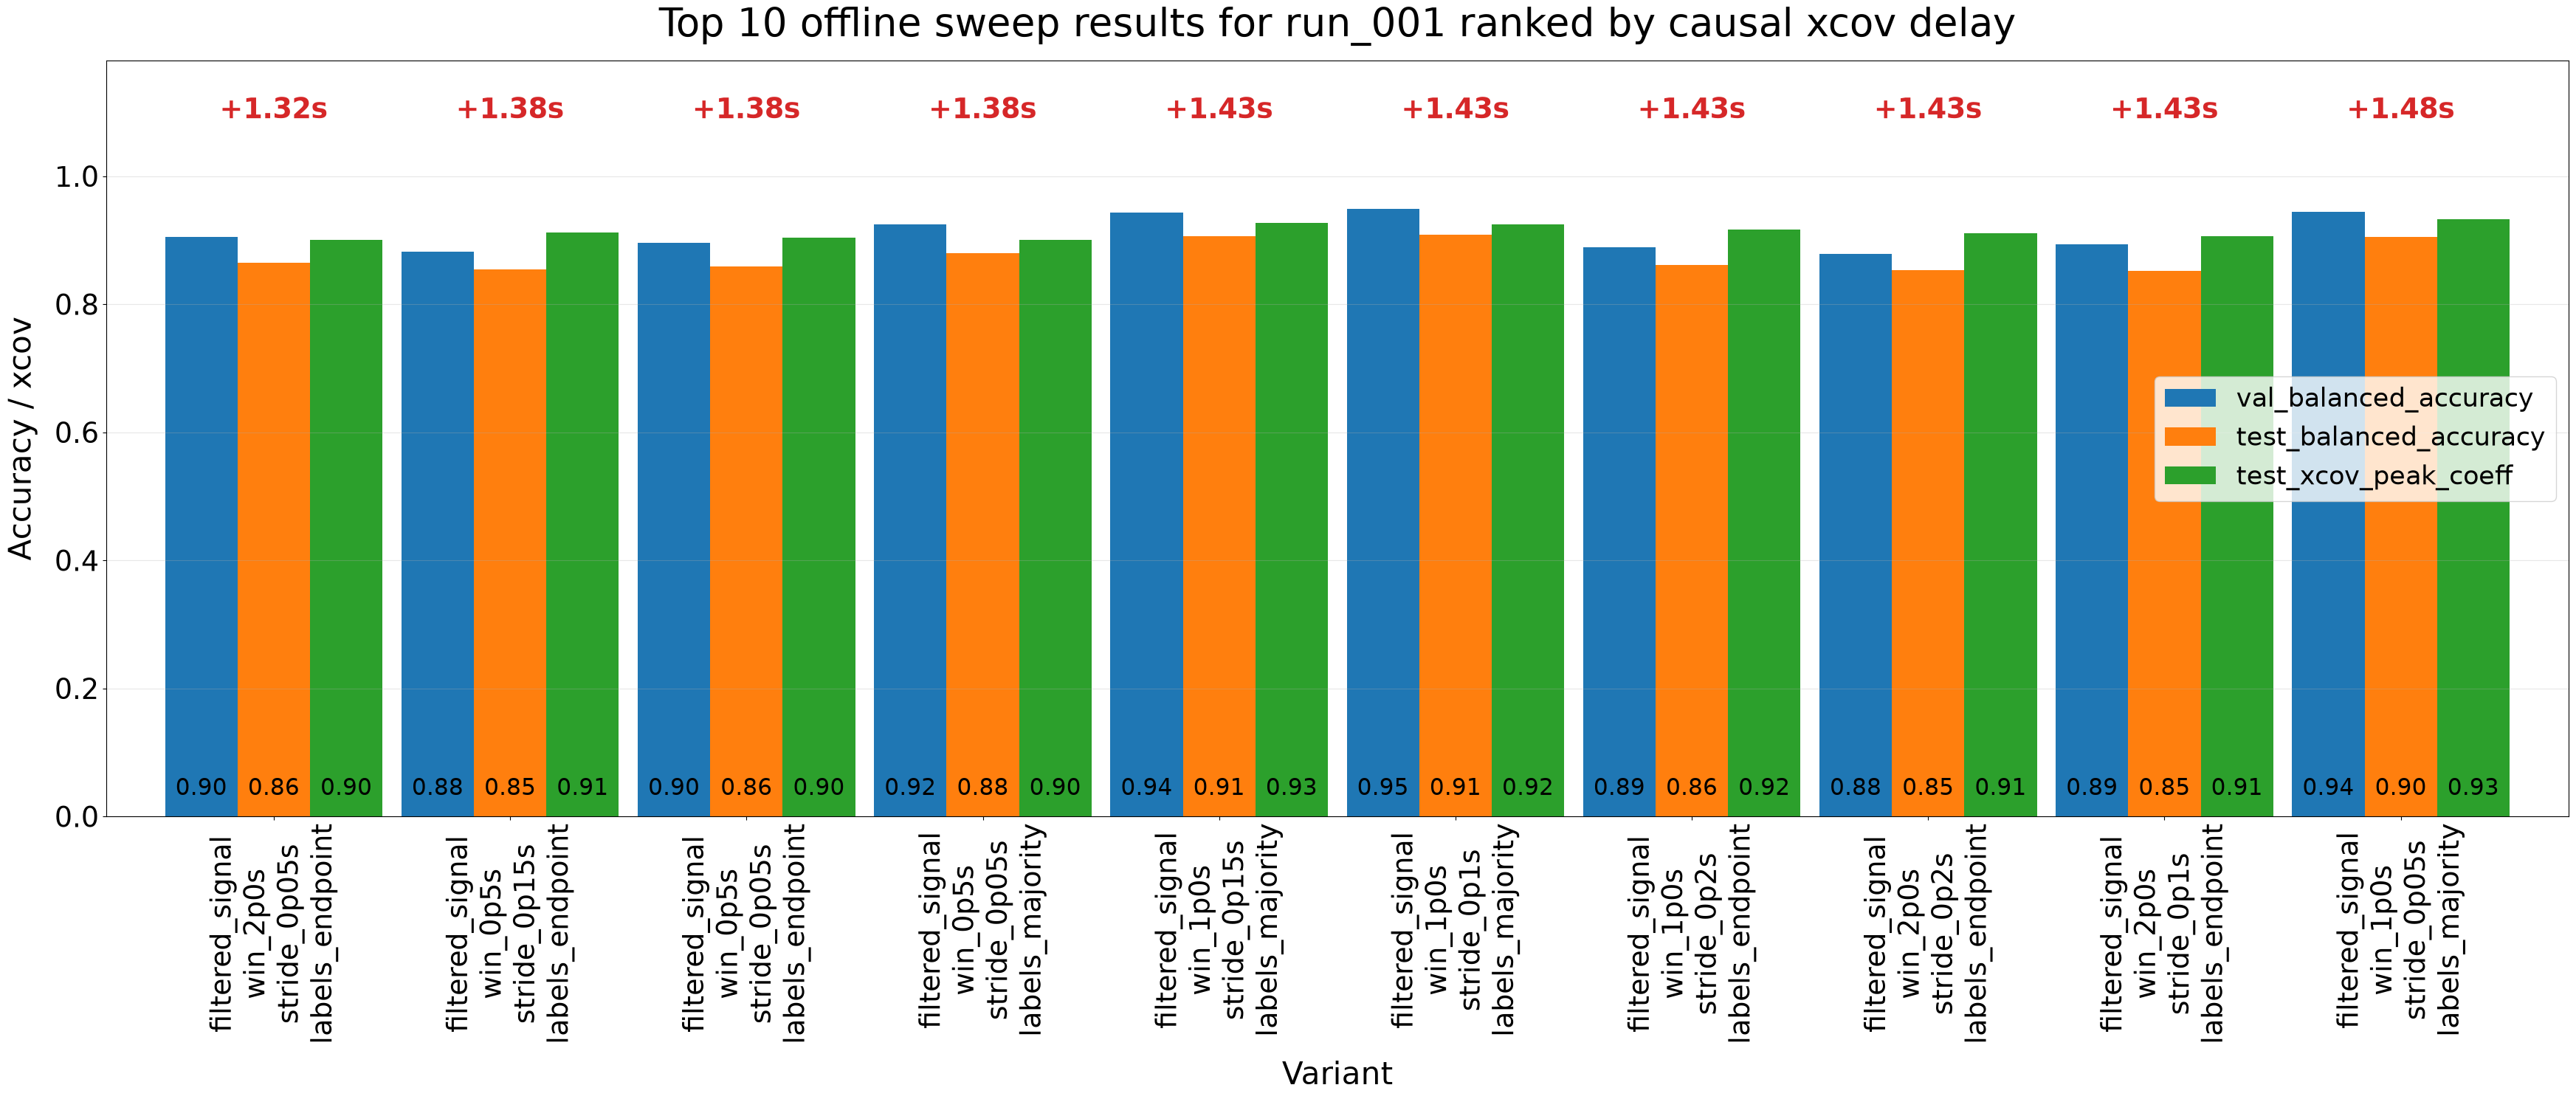

In [12]:
DELAY_TOP_N_VARIANTS = 10
delay_plot_df = summary.copy()
delay_plot_df['test_xcov_delay_sec'] = pd.to_numeric(delay_plot_df['test_xcov_delay_sec'], errors='coerce')
delay_plot_df['test_xcov_peak_coeff'] = pd.to_numeric(delay_plot_df['test_xcov_peak_coeff'], errors='coerce')

# For causal realtime interpretation, nonnegative delay is preferred. Negative
# xcov delay means the prediction trace leads the label trace, so those variants
# are shown only after all variants with valid nonnegative delay.
delay_plot_df['delay_rank_group'] = 2
delay_plot_df.loc[delay_plot_df['test_xcov_delay_sec'] >= 0, 'delay_rank_group'] = 0
delay_plot_df.loc[delay_plot_df['test_xcov_delay_sec'] < 0, 'delay_rank_group'] = 1

delay_plot_df = (
    delay_plot_df
    .sort_values(
        ['delay_rank_group', 'test_xcov_delay_sec', 'test_xcov_peak_coeff', 'test_balanced_accuracy'],
        ascending=[True, True, False, False],
        na_position='last',
    )
    .head(DELAY_TOP_N_VARIANTS)
    .copy()
)
delay_plot_df['variant_short'] = delay_plot_df['variant'].str.replace('__', '\n', regex=False)

ax = delay_plot_df.plot.bar(
    x='variant_short',
    y=['val_balanced_accuracy', 'test_balanced_accuracy', 'test_xcov_peak_coeff'],
    figsize=(35, 15),
    width=0.92,
)
ax.set_xlabel('Variant', fontsize=30, labelpad=16)
ax.set_ylabel('Accuracy / xcov', fontsize=30, labelpad=16)
ax.set_ylim(0.0, 1.18)
ax.set_title(
    f'Top {DELAY_TOP_N_VARIANTS} offline sweep results for {RUN_ID} ranked by causal xcov delay',
    fontsize=38,
    pad=24,
)
ax.tick_params(axis='x', labelsize=27, rotation=90)
ax.tick_params(axis='y', labelsize=27)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                0.025,
                f'{float(height):.2f}',
                ha='center',
                va='bottom',
                fontsize=22,
                color='black',
                clip_on=True,
            )
ax.legend(fontsize=25, loc='center right')
ax.grid(True, axis='y', alpha=0.3)

delay_values = delay_plot_df['test_xcov_delay_sec']
for idx, value in enumerate(delay_values):
    if pd.notna(value):
        ax.text(
            idx,
            1.08,
            f'{float(value):+.2f}s',
            ha='center',
            va='bottom',
            fontsize=27,
            color='tab:red',
            fontweight='bold',
        )
plt.tight_layout()


## Inspect best variant predictions


Best variant by xcov peak coefficient: filtered_signal__win_2p0s__stride_0p05s__labels_majority
Best xcov peak coefficient: 0.9774026939518574
Best xcov delay sec: 1.695
Best predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\filtered_signal__win_2p0s__stride_0p05s__labels_majority\realtime_trial_01_raw_labeled_test_predictions.csv
Best aligned EEG/predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline\offline_001\sweeps\filtered_signal__win_2p0s__stride_0p05s__labels_majority\realtime_trial_01_raw_labeled_test_predictions_aligned_eeg.csv


,start_sample,end_sample,start_time_sec,end_time_sec,label,true_label,pred_label,correct,prob_Eyes Open,prob_Eyes Closed
556,5560,5960,27.80,29.80,1,1,1,True,0.000442,0.999558
557,5570,5970,27.85,29.85,1,1,1,True,0.000414,0.999586
558,5580,5980,27.90,29.90,1,1,1,True,0.000456,0.999544
559,5590,5990,27.95,29.95,1,1,1,True,0.000441,0.999559
560,5600,6000,28.00,30.00,1,1,1,True,0.000488,0.999512


,n_cues,n_matched_first_correct,mean_cue_to_first_correct_sec,median_cue_to_first_correct_sec,n_matched_predicted_transition,mean_cue_to_predicted_transition_sec,median_cue_to_predicted_transition_sec,n_matched_sustained,mean_cue_to_sustained_prediction_sec,median_cue_to_sustained_prediction_sec
0,3,3,1.59,1.675,3,1.59,1.675,3,1.59,1.675


,target_label,target_label_name,prediction_signal_column,xcov_delay_sec,xcov_lag_samples,xcov_peak_coeff,max_lag_sec,n_valid_samples
0,1,Eyes Closed,prob_Eyes Closed,1.695,339,0.977403,10.0,5600


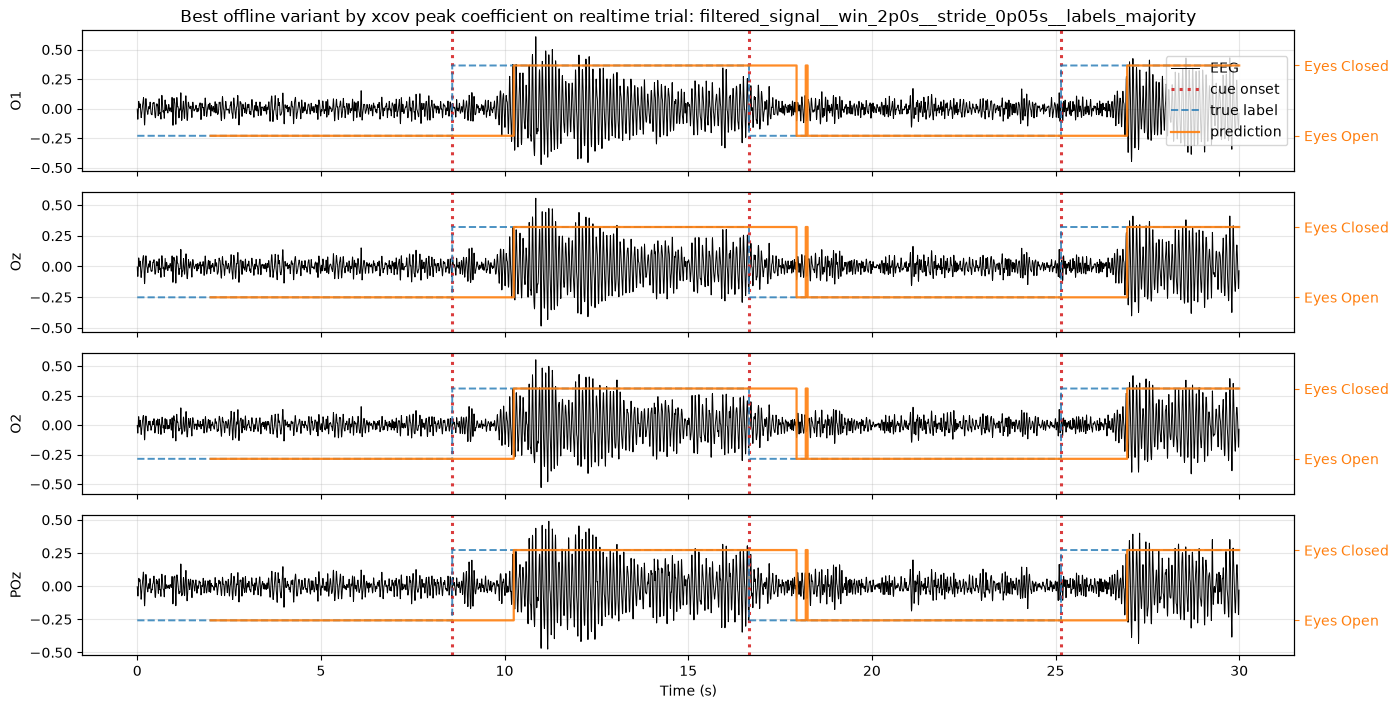

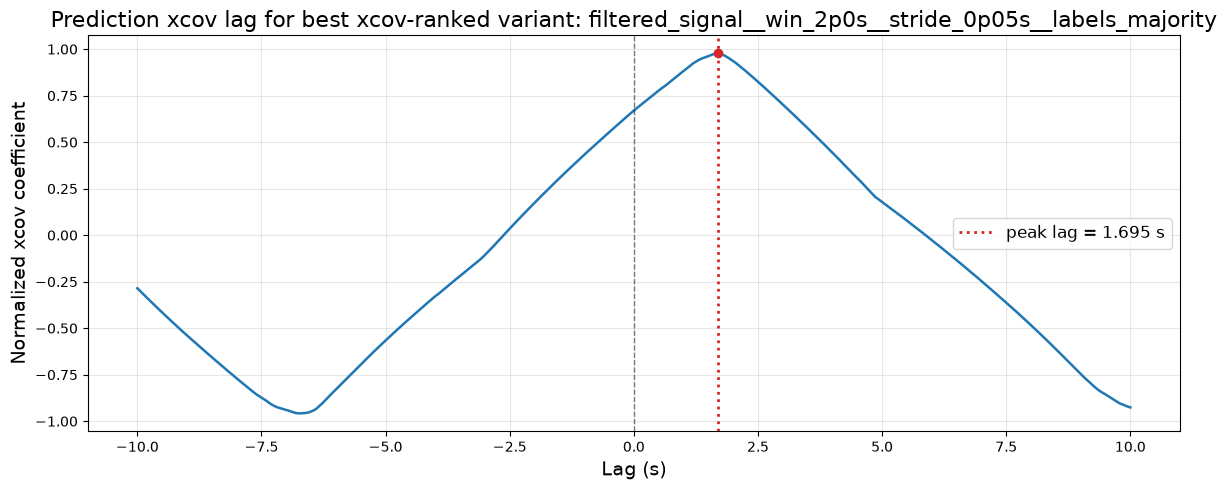

In [9]:
best = summary.iloc[0]
best_variant_dir = Path(best['variant_dir'])
best_pred_csv = best_variant_dir / f'{TEST_LABELED_NPZ.stem}_test_predictions.csv'
best_aligned_pred_csv = Path(best.get('test_aligned_prediction_csv', best_variant_dir / f'{TEST_LABELED_NPZ.stem}_test_predictions_aligned_eeg.csv'))
best_cue_delay_summary_csv = best_variant_dir / f'{TEST_LABELED_NPZ.stem}_test_cue_delay_summary.csv'
best_xcov_delay_summary_csv = best_variant_dir / f'{TEST_LABELED_NPZ.stem}_test_xcov_delay_summary.csv'
best_xcov_curve_csv = best_variant_dir / f'{TEST_LABELED_NPZ.stem}_test_xcov_curve.csv'

print('Best variant by xcov peak coefficient:', best['variant'])
print('Best xcov peak coefficient:', best.get('test_xcov_peak_coeff'))
print('Best xcov delay sec:', best.get('test_xcov_delay_sec'))
print('Best predictions:', best_pred_csv)
print('Best aligned EEG/predictions:', best_aligned_pred_csv)

best_predictions = pd.read_csv(best_pred_csv)
display(best_predictions.tail())

best_cue_delay_summary = pd.read_csv(best_cue_delay_summary_csv) if best_cue_delay_summary_csv.exists() else None
best_xcov_delay_summary = pd.read_csv(best_xcov_delay_summary_csv) if best_xcov_delay_summary_csv.exists() else None
best_xcov_curve = pd.read_csv(best_xcov_curve_csv) if best_xcov_curve_csv.exists() else None

if best_cue_delay_summary is not None:
    display(best_cue_delay_summary)
if best_xcov_delay_summary is not None:
    display(best_xcov_delay_summary)

fig, axes = plot_predictions_overlay(
    TEST_LABELED_NPZ,
    best_predictions,
    max_duration_sec=None,
    channel_names=EEG_CHANNEL_NAMES,
    show_true_labels=True,
)
axes[0].set_title(f"Best offline variant by xcov peak coefficient on realtime trial: {best['variant']}")
overlay_legend = axes[0].get_legend()
if overlay_legend is not None:
    try:
        overlay_legend.set_loc('center right')
    except AttributeError:
        overlay_legend._loc = 7

if best_xcov_curve is not None and best_xcov_delay_summary is not None:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(best_xcov_curve['lag_sec'], best_xcov_curve['xcov_coeff'], linewidth=1.8)
    peak_delay = float(best_xcov_delay_summary.loc[0, 'xcov_delay_sec'])
    peak_coeff = float(best_xcov_delay_summary.loc[0, 'xcov_peak_coeff'])
    ax.axvline(peak_delay, linestyle=':', color='tab:red', linewidth=2.0, label=f'peak lag = {peak_delay:.3f} s')
    ax.scatter([peak_delay], [peak_coeff], color='tab:red', zorder=3)
    ax.axvline(0.0, linestyle='--', color='black', alpha=0.5, linewidth=1.0)
    ax.set_xlabel('Lag (s)', fontsize=14)
    ax.set_ylabel('Normalized xcov coefficient', fontsize=14)
    ax.set_title(f"Prediction xcov lag for best xcov-ranked variant: {best['variant']}", fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12, loc='center right')
    plt.tight_layout()
